VALUTAZIONI

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_absolute_percentage_error
import sys
import os
import ast
from pathlib import Path
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
import lightgbm as lgb
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import ElasticNet
from sklearn.preprocessing import StandardScaler
import subprocess
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
import seaborn as sns
import matplotlib.dates as mdates


In [22]:
from google.colab import drive
# 1. Collega Drive
drive.mount('/content/drive')

# 2. Vai nella cartella dove hai i file e la cartella audio
%cd "/content/drive/MyDrive/Magistrale/Tesi/Fase2"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/Magistrale/Tesi/Fase2


In [23]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
np.set_printoptions(threshold=sys.maxsize)

DATASET_INPUT_PATH = f"audio_dataset.csv"
SUMMARY_CSV_PATH="best_models_summary_ordered.csv"
TOP=1
MAIN_METRIC='MAE' #'MAE'

In [24]:
  # 1. Creazione della cartella di output se non esiste
OUTPUT_DIR = Path("PredizioniVSGroundTruth")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_AVERAGES_DIR = Path("MedieSeeds")
OUTPUT_AVERAGES_DIR.mkdir(parents=True, exist_ok=True)

CARICAMENTO DATI

In [25]:
df = pd.read_csv(DATASET_INPUT_PATH, index_col=0)

In [26]:
def plot_predictions(y_test, y_pred):
  """Confronta y_test e y_pred creando un grafico giornaliero,

  impostando la medesima scala Y e la medesima scala X (intervallo di 24 ore)
  per tutti i grafici, includendo il giorno nel titolo e salvando in un percorso.
  """

  # 2. Creazione del DataFrame di supporto
  df_plot = pd.DataFrame({'y_test': y_test, 'y_pred': y_pred}, index=y_test.index)

  # 3. Estrazione del timestamp e conversione in datetime
  timestamps = (
      df_plot.index.str.replace('audio_', '', regex=False)
      .str.replace('.wav', '', regex=False)
      .str.strip()
  )
  df_plot['datetime'] = pd.to_datetime(timestamps, format='%Y-%m-%dT%H-%M-%S')
  df_plot['date'] = df_plot['datetime'].dt.date

  # Ordinamento globale cronologico
  df_plot = df_plot.sort_values(by='datetime')

  # 4. Calcolo della scala fissa comune per l'asse Y su tutto il dataset
  y_min = min(df_plot['y_test'].min(), df_plot['y_pred'].min())
  y_max = max(df_plot['y_test'].max(), df_plot['y_pred'].max())
  padding = (
      (y_max - y_min) * 0.05 if y_max != y_min else 1.0
  )  # piccolo margine estetico del 5%
  ylimits = (y_min - padding, y_max + padding)

  # 5. Iterazione per ogni giorno unico e generazione del grafico
  for giorno, gruppo in df_plot.groupby('date'):
    fig, ax = plt.subplots(figsize=(12, 5))

    ax.plot(
        gruppo['datetime'],
        gruppo['y_test'],
        label='Ground Truth',
        color='blue',
        marker='o',
        linestyle='-',
        alpha=0.8,
    )
    ax.plot(
        gruppo['datetime'],
        gruppo['y_pred'],
        label='Predizioni',
        color='orange',
        marker='x',
        linestyle='--',
        alpha=0.8,
    )

    ''' #No linee interpolate
    ax.plot(
        gruppo['datetime'],
        gruppo['y_test'],
        label='Ground Truth',
        color='blue',
        marker='o',
        linestyle='None',  # Nessuna linea, solo il puntino
        alpha=0.8,
    )
    ax.plot(
        gruppo['datetime'],
        gruppo['y_pred'],
        label='Predizioni',
        color='orange',
        marker='x',
        linestyle='None',  # Nessuna linea, solo il marker
        alpha=0.8,
    )
    '''

    # Personalizzazioni richieste: Titolo con il giorno e asse X 'Timestamp'
    ax.set_title(
        f'Predizione vs Ground Truth - {giorno}',
        fontsize=14,
        fontweight='bold',
    )
    ax.set_xlabel('Timestamp', fontsize=12)
    ax.set_ylabel('Portata', fontsize=12)

    # Fissa la medesima scala Y
    ax.set_ylim(ylimits)

    # Fissa la medesima scala X sull'intero arco della giornata (dalle 00:00:00 alle 23:59:59)
    start_of_day = pd.to_datetime(str(giorno) + ' 00:00:00')
    end_of_day = pd.to_datetime(str(giorno) + ' 23:59:59')
    ax.set_xlim([start_of_day, end_of_day])

    # Formattazione asse X (ore:minuti:secondi) e rotazione pulita
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))
    fig.autofmt_xdate()

    ax.legend(fontsize=12)
    ax.grid(True, linestyle=':', alpha=0.6)

    # Salvataggio del grafico nella cartella prefissata
    filename = OUTPUT_DIR / f'Confronto_{giorno}.png'
    plt.tight_layout()
    plt.savefig(filename, dpi=300)
    plt.show()
    plt.close(fig)  # Chiude la figura per liberare memoria

  print(
      f"Tutti i grafici sono stati salvati correttamente nella cartella:"
      f" '{OUTPUT_DIR.resolve()}'"
  )

In [27]:
# 2. Calcoliamo il "Peso Hardware" per ogni combinazione testata
def train_evaluate_model(row):

  model_name=row["Modello"].lower()

  SEED=row["Seed"]

  # Estrazione parametri e metadati dalla riga
  parameters = ast.literal_eval(row['Iperparametri'])
  rank=row["Rank"]
  print(f"Allenando il modello di {model_name} n.{rank} con parametri: {parameters} ...")
  current_df=df.copy()
  model={}

  # Inizializzazione del modello
  match model_name:
      case "randomforest":
        model = RandomForestRegressor(**parameters, random_state=SEED)
      case "xgboost":
        if "device" in parameters: parameters.pop("device")
        model = xgb.XGBRegressor(**parameters, base_score = 0, tree_method='hist', random_state=SEED)
      case "lightgbm":
        model = lgb.LGBMRegressor(**parameters, random_state=SEED, verbosity=-1, device="cpu")
      case "elasticnet":
        model = ElasticNet(**parameters, random_state=SEED)
      case "linearregression":
        model = LinearRegression()
      case _:
        print("Modello non trovato")
        return

  # 2. PREPARAZIONE X e y
  target_column = 'portata'
  X = current_df.drop(columns=[target_column])
  y = current_df[target_column]

  # 3. SPLIT TRAIN/TEST
  # Dividiamo i dati: 80% training, 20% test
  #X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED)
  X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED)

  if model_name=="elasticnet" or model_name=="linearregression":
    print("Standardizzazione delle feature...")
    scaler = StandardScaler()
    scaler.set_output(transform="pandas")
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)
    pca = PCA(n_components=0.90, random_state=SEED)
    pca.set_output(transform="pandas")

    print(f"Feature originali: {X_train.shape[1]}")

    # Trasforma i dati (X_train e X_test erano già stati scalati col tuo scaler)
    X_train = pca.fit_transform(X_train)
    X_test = pca.transform(X_test)

    print(f"Feature dopo PCA: {X_train.shape[1]}")

  # Addestramento del modello
  model.fit(X_train, y_train)

  y_pred=model.predict(X_test)

  mae_test = mean_absolute_error(y_test, y_pred)
  me_test = np.mean(y_test - y_pred)
  mape_test = mean_absolute_percentage_error(y_test, y_pred) * 100
  r2_test = r2_score(y_test, y_pred)
  mse_test=mean_squared_error(y_test, y_pred)
  rmse_test = np.sqrt(mse_test)

  print(f"--- PERFORMANCE MODELLO (TESTING) ---")
  print(f"R^2 Score: {r2_test:.4f}")
  print(f"MAE: {mae_test:.4f}")
  print(f"ME: {me_test:.4f}")
  print(f"MAPE: {mape_test:.2f}%")
  print(f"MSE: {mse_test:.4f}")
  print(f"RMSE: {rmse_test:.4f}")

  plot_predictions(y_test, y_pred)

  return

In [28]:
# 1. Estraiamo i risultati della RandomizedSearch
results = pd.read_csv(SUMMARY_CSV_PATH)

Grafico salvato: MedieSeeds/Media_R².png


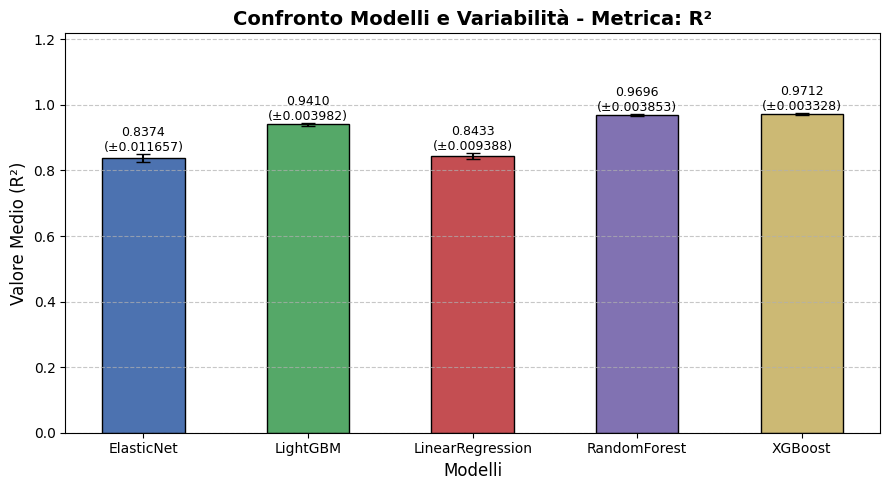

Grafico salvato: MedieSeeds/Media_MAE.png


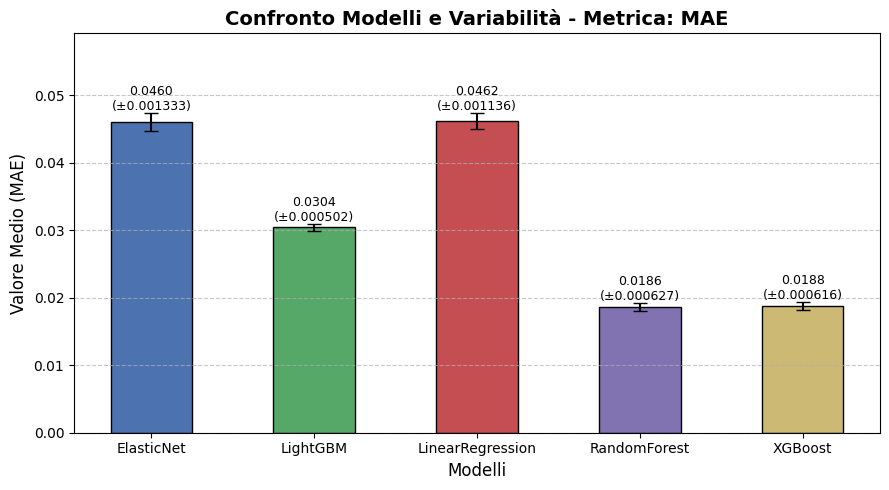

Grafico salvato: MedieSeeds/Media_ME.png


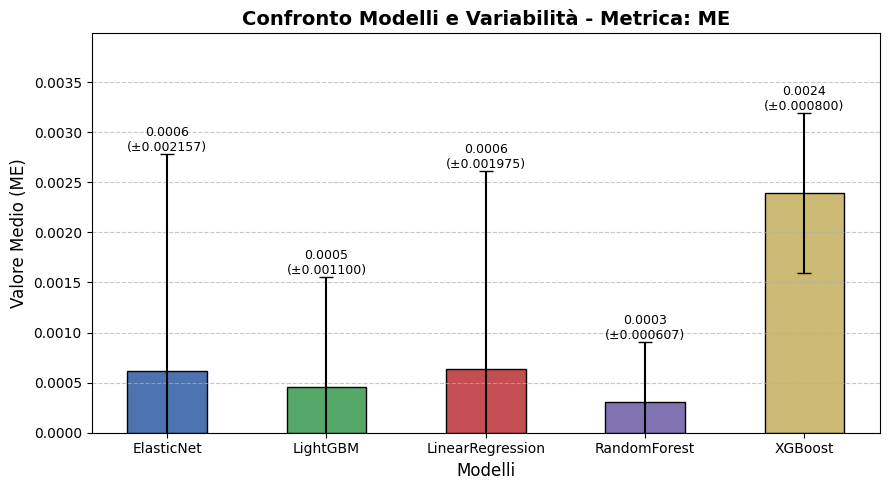

Grafico salvato: MedieSeeds/Media_MAPE.png


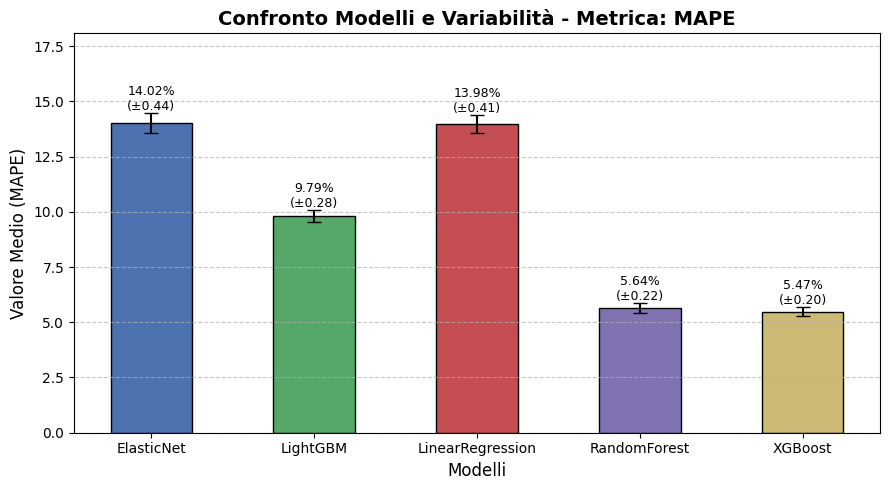

Grafico salvato: MedieSeeds/Media_MSE.png


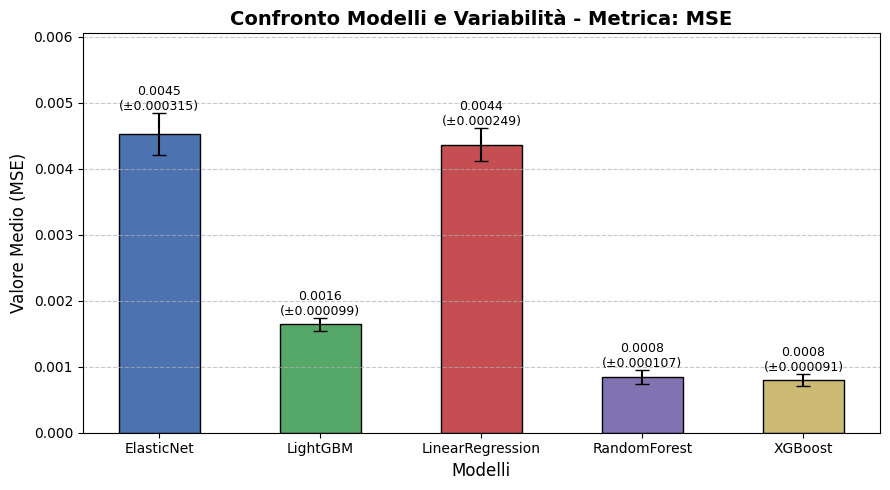

Grafico salvato: MedieSeeds/Media_RMSE.png


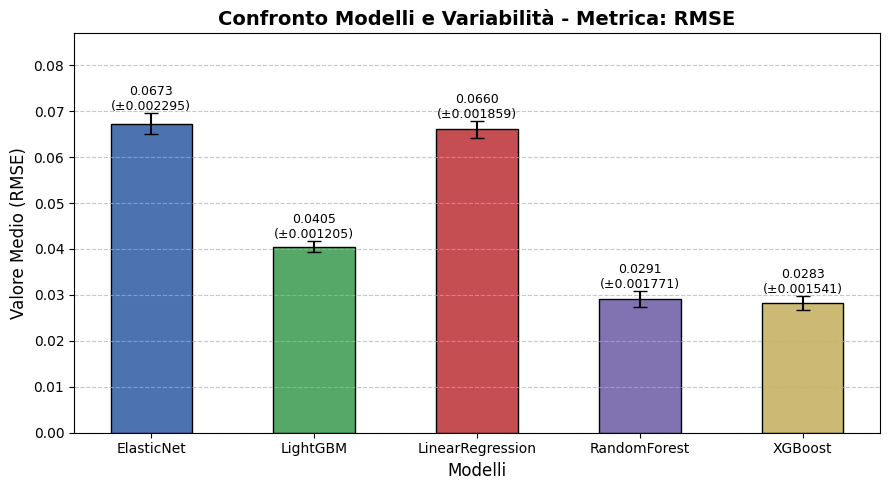

In [29]:
# 1. Seleziona tutte le colonne che terminano con "_test"
test_cols = [col for col in results.columns if col.endswith('_test')]

# 2. Pulisci e converti in numerico le colonne (rimuove eventuali '%' e stringhe)
for col in test_cols:
    cleaned = results[col].astype(str).str.replace('%', '', regex=False)
    results[col] = pd.to_numeric(cleaned, errors='coerce')

# 3. Raggruppa per il campo "Modello" calcolando media e deviazione standard
df_mean = results.groupby('Modello')[test_cols].mean()
df_std = results.groupby('Modello')[test_cols].std().fillna(0.0) # Gestione di eventuali NaN se c'è un solo seed per modello

# Palette di colori distinti per ogni tipologia di modello (ripresa dal primo script)
model_colors = ['#4C72B0', '#55A868', '#C44E52', '#8172B2', '#CCB974', '#64B5CD']

# 4. Genera un grafico separato per ogni campo _test con lo stile avanzato
for col in test_cols:
    clean_metric_name = col.replace('_test', '')

    plt.figure(figsize=(9, 5))

    models = df_mean.index.tolist()
    mean_scores = df_mean[col].tolist()
    std_scores = df_std[col].tolist()

    # Seleziona i colori in base al numero di modelli disponibili
    current_colors = model_colors[:len(models)]

    # Crea il bar plot con error bar e i colori personalizzati
    bars = plt.bar(
        models,
        mean_scores,
        yerr=std_scores,
        capsize=5,
        edgecolor='black',
        color=current_colors,
        width=0.5,
        ecolor='black'
    )

    # Calcolo dinamico del limite Y per evitare sovrapposizioni con le etichette o il titolo
    if mean_scores:
        max_top = max([m + (s if pd.notna(s) else 0) for m, s in zip(mean_scores, std_scores)])
        plt.ylim(0, max_top * 1.25 if max_top > 0 else 1.0)

    plt.title(f'Confronto Modelli e Variabilità - Metrica: {clean_metric_name}', fontsize=14, fontweight='bold')
    plt.xlabel('Modelli', fontsize=12)
    plt.ylabel(f'Valore Medio ({clean_metric_name})', fontsize=12)
    plt.xticks(rotation=0)  # Puoi metterlo a 45 se i nomi dei modelli sono lunghi: rotation=45, ha='right'
    plt.grid(axis='y', linestyle='--', alpha=0.7)

    # Mostra i valori e la deviazione standard sopra le barre con la formattazione condizionale (MAPE vs altri)
    for bar, std_val in zip(bars, std_scores):
        bar_height = bar.get_height()
        if pd.notna(bar_height):
            s_val = std_val if pd.notna(std_val) else 0.0
            if clean_metric_name.lower() == 'mape':
                text_label = f'{bar_height:.2f}%\n(±{s_val:.2f})'
            else:
                text_label = f'{bar_height:.4f}\n(±{s_val:.6f})'

            plt.text(
                bar.get_x() + bar.get_width() / 2.,
                bar_height + s_val,
                text_label,
                ha='center', va='bottom', fontsize=9
            )

    plt.tight_layout()

    # Salvataggio del grafico (aggiunta estensione .png per sicurezza)
    filename = OUTPUT_AVERAGES_DIR / f"Media_{clean_metric_name}.png"
    plt.savefig(filename, dpi=300)
    print(f"Grafico salvato: {filename}")

    plt.show()
    plt.close()

Allenando il modello di xgboost n.1 con parametri: {'subsample': 0.8, 'n_estimators': 25, 'max_depth': 9, 'learning_rate': 0.2, 'gamma': 0, 'colsample_bytree': 1.0} ...
--- PERFORMANCE MODELLO (TESTING) ---
R^2 Score: 0.9748
MAE: 0.0179
ME: 0.0018
MAPE: 5.30%
MSE: 0.0007
RMSE: 0.0267


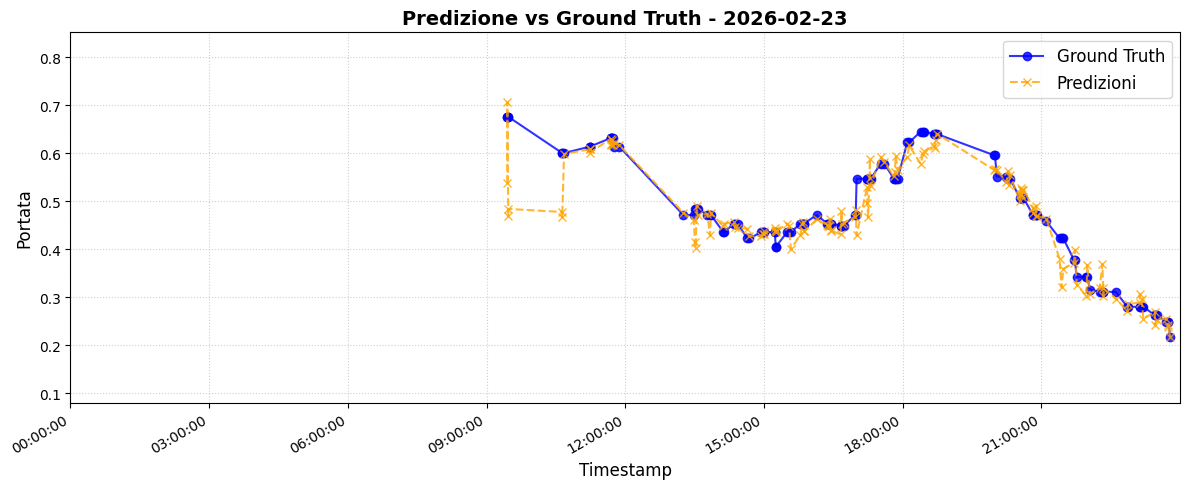

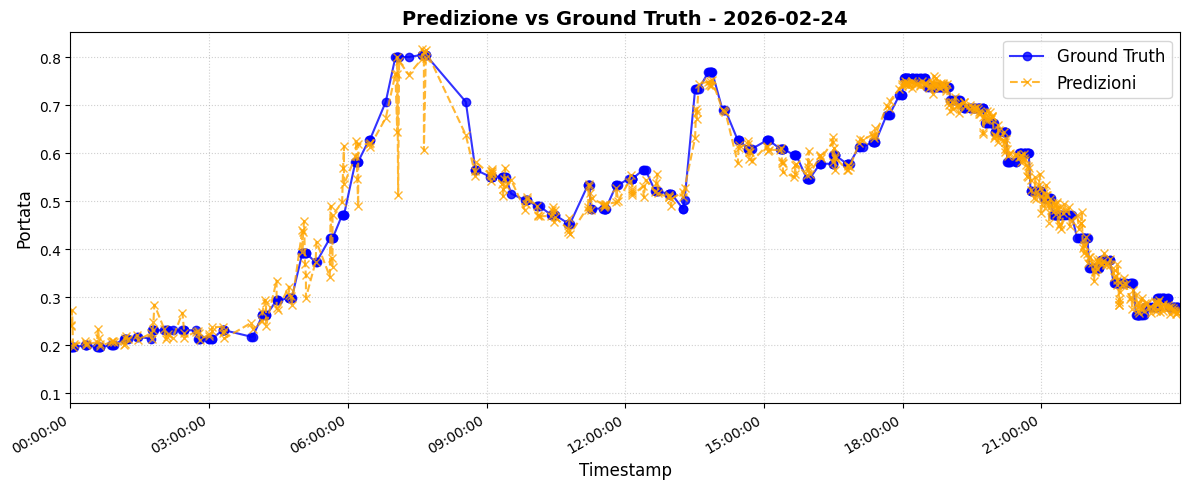

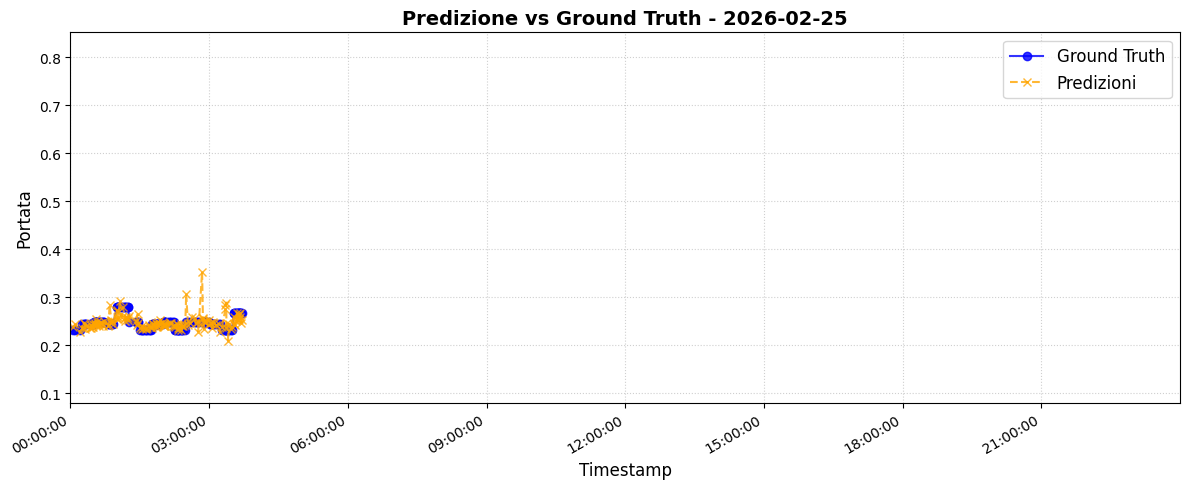

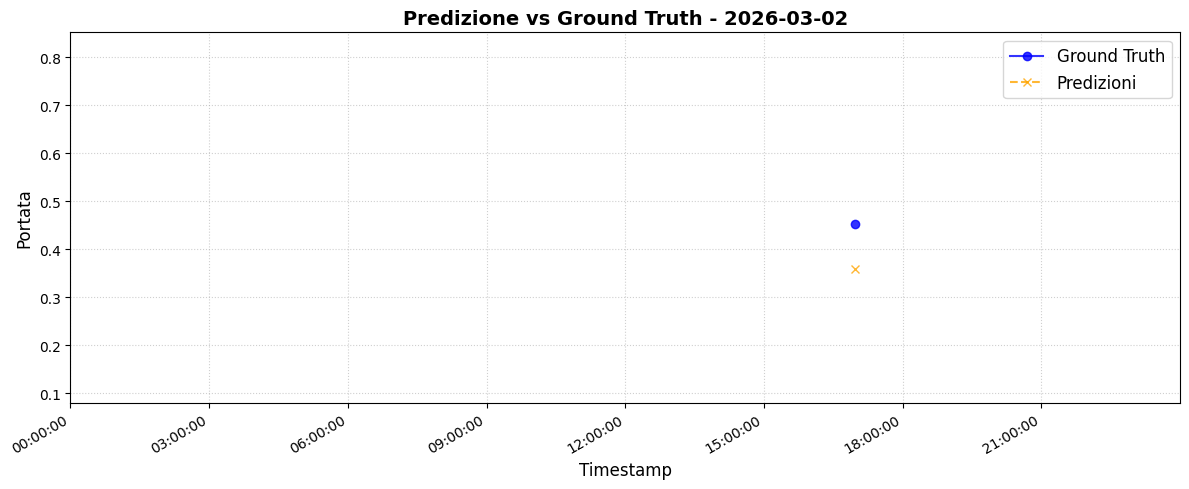

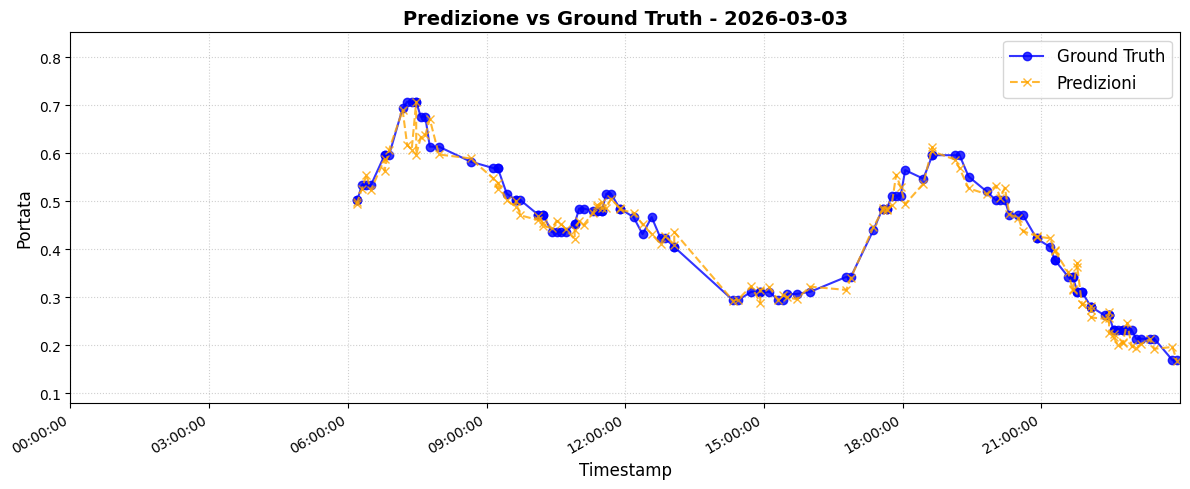

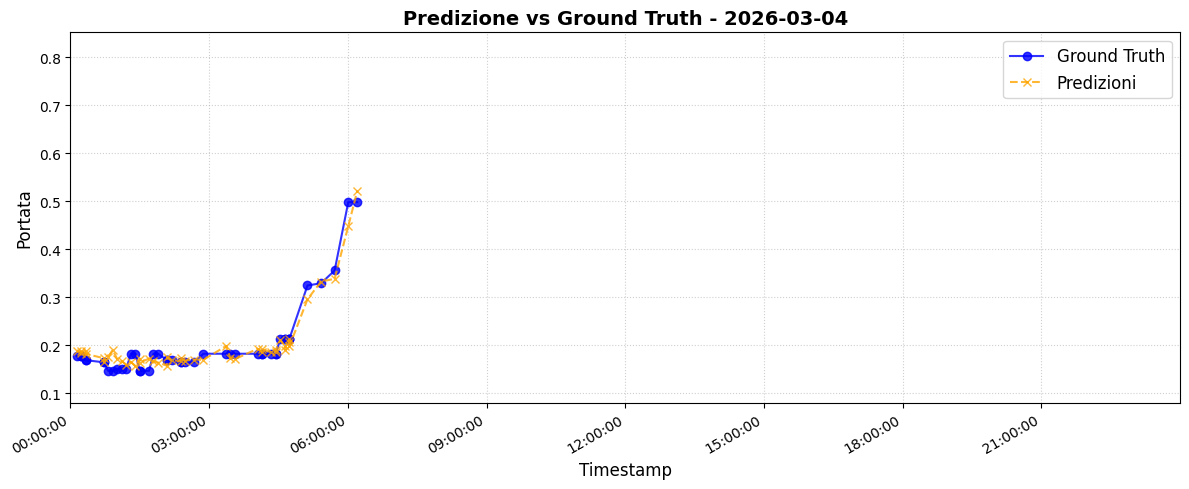

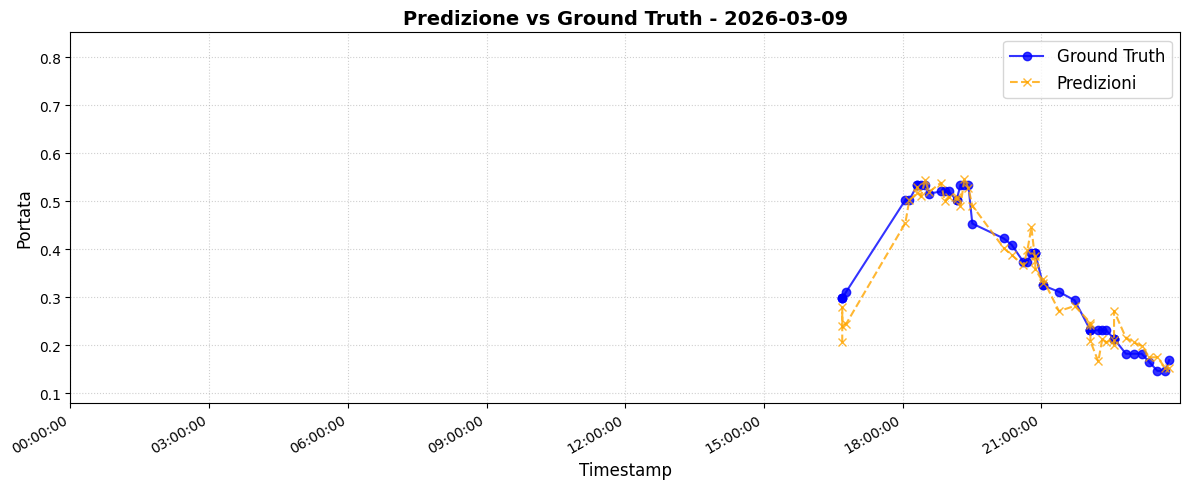

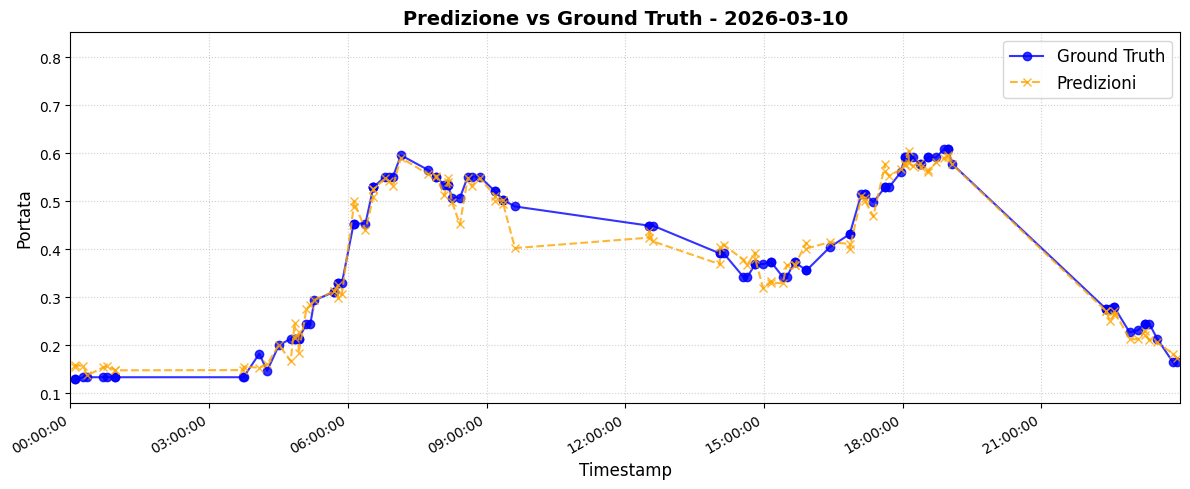

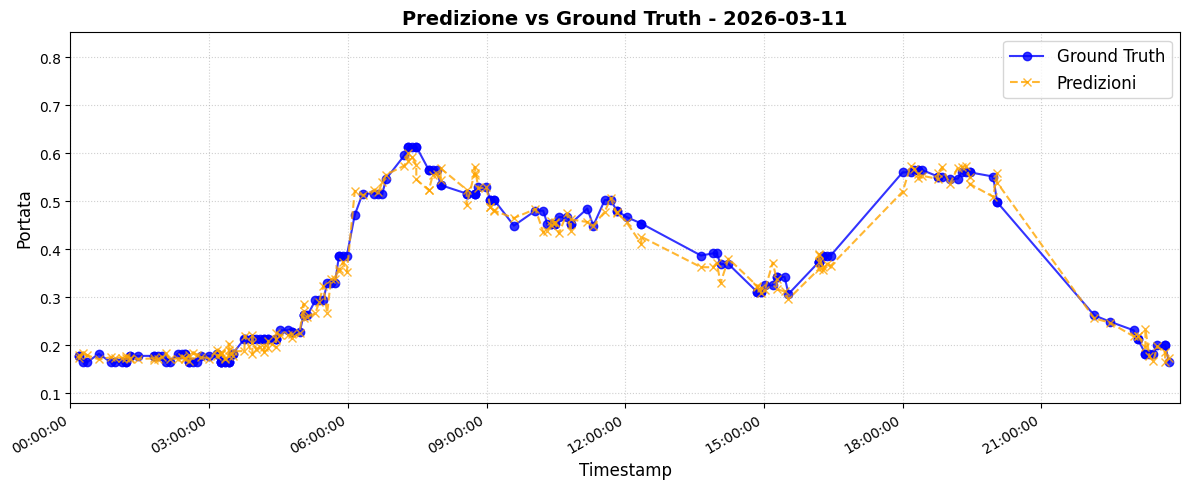

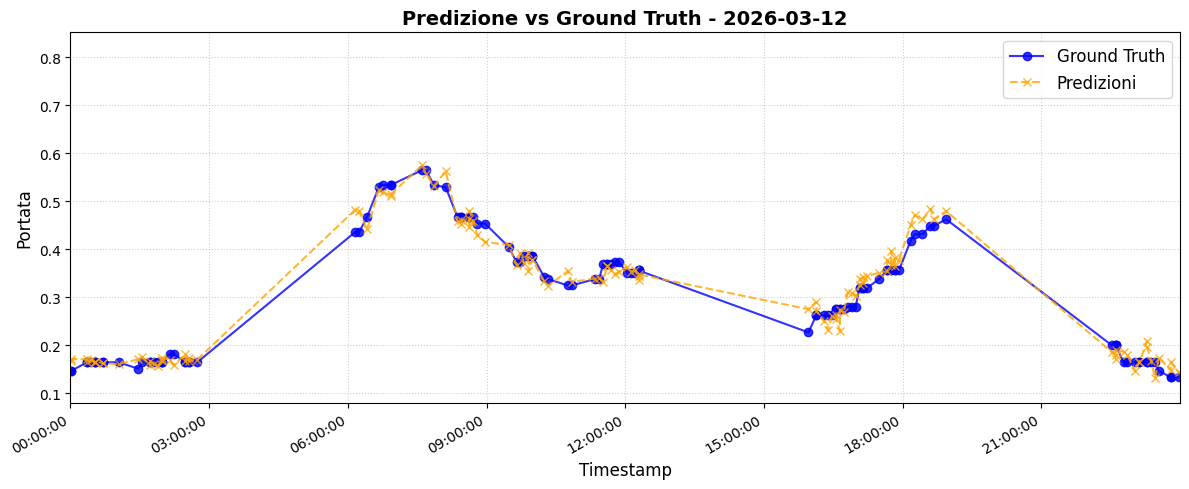

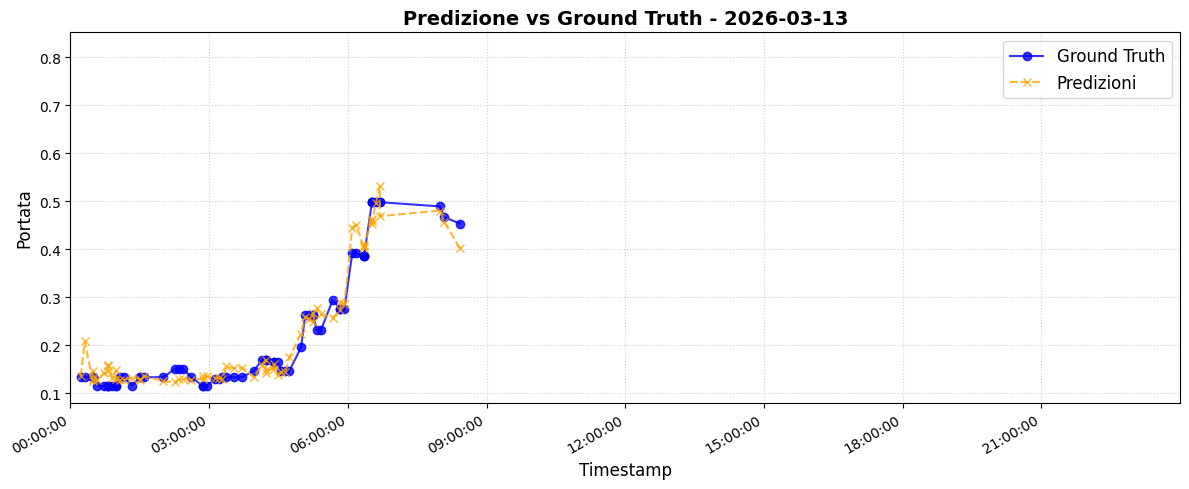

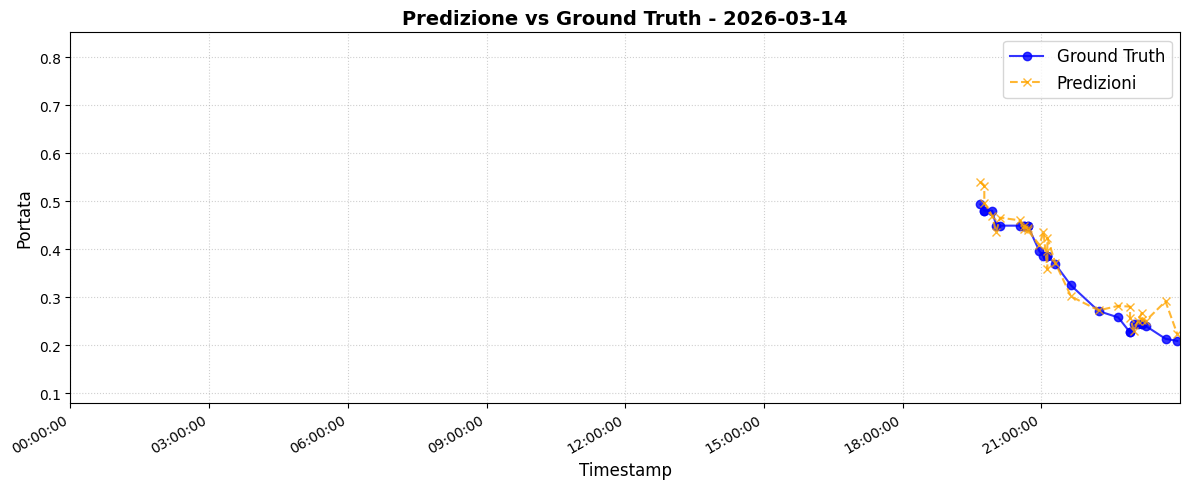

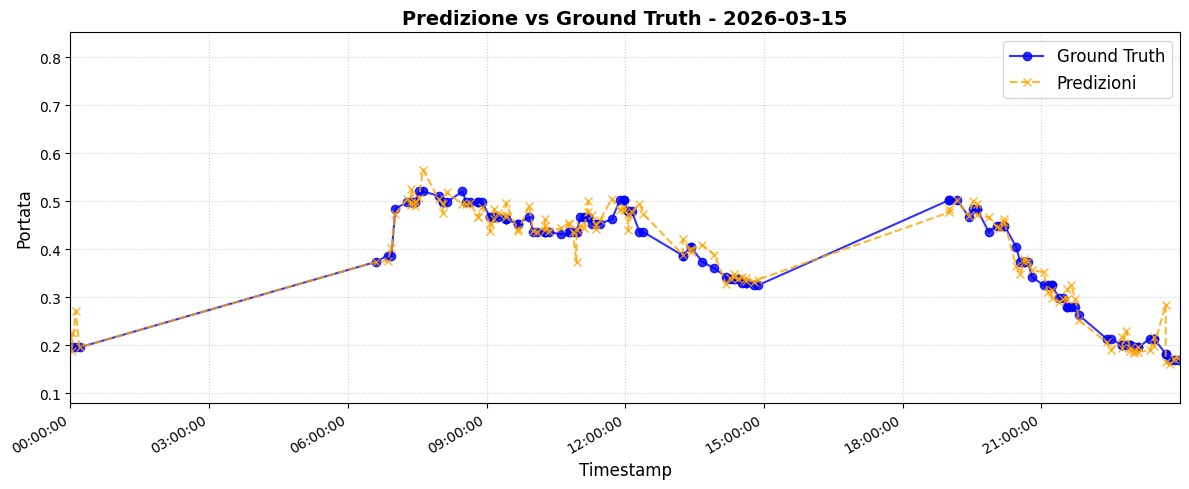

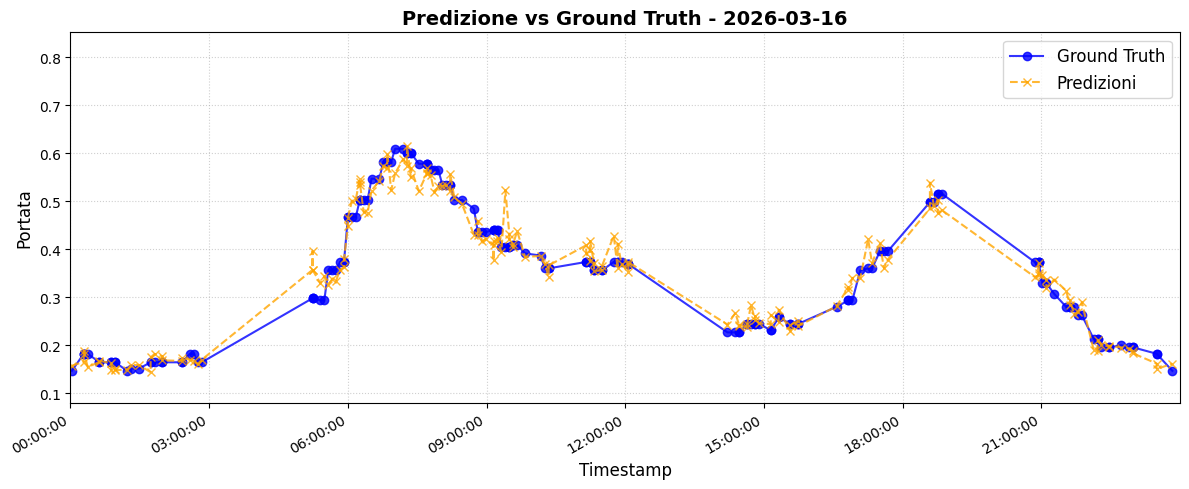

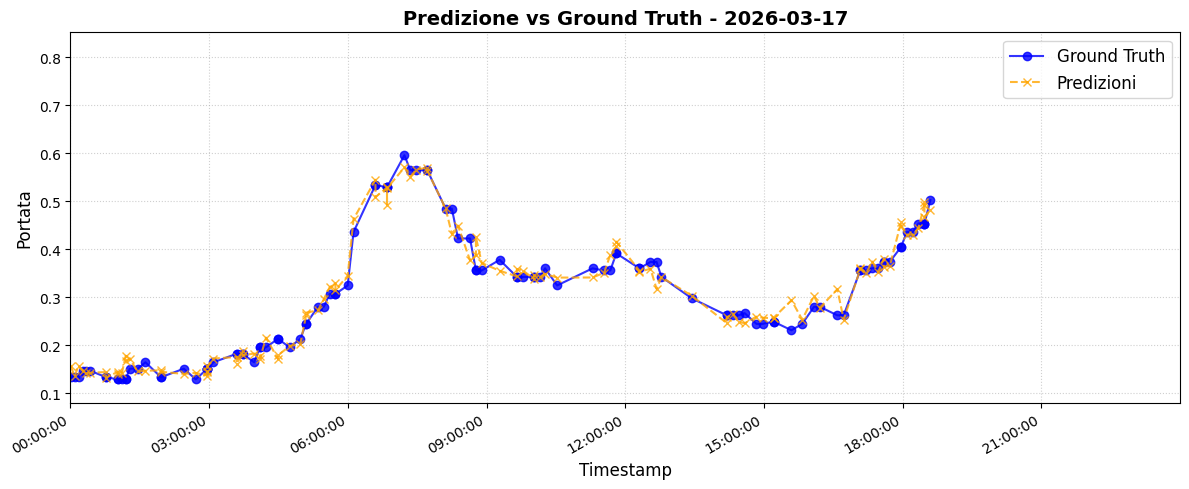

Tutti i grafici sono stati salvati correttamente nella cartella: '/content/drive/MyDrive/Magistrale/Tesi/Fase2/PredizioniVSGroundTruth'


,0
0,None


In [30]:
top_mae = results.nsmallest(TOP, "MAE_test").copy()
top_mae.apply(
  lambda row: train_evaluate_model(row),
  axis=1
)